## Problem 4: Bias-Variance Trade-off

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

**Read Fama-French factor data**

In [2]:
ff3_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip"

ff3_raw = pd.read_csv(
    ff3_url,
    compression="zip",
    skiprows=3
)

ff3_raw.head()

,Unnamed: 0,Mkt-RF,SMB,HML,RF
0,192607,2.89,-2.55,-2.39,0.22
1,192608,2.64,-1.14,3.81,0.25
2,192609,0.38,-1.36,0.05,0.23
3,192610,-3.27,-0.14,0.82,0.32
4,192611,2.54,-0.11,-0.61,0.31


**Clean Fama-French factor data**

In [3]:
ff3 = ff3_raw.copy()

ff3 = ff3.rename(columns={ff3.columns[0]: "Date"})

ff3 = ff3[ff3["Date"].astype(str).str.isnumeric()]
ff3 = ff3[ff3["Date"].astype(str).str.len() == 6]

ff3["Date"] = pd.to_datetime(ff3["Date"].astype(str), format="%Y%m")

ff3["Mkt-RF"] = pd.to_numeric(ff3["Mkt-RF"], errors="coerce")
ff3["SMB"] = pd.to_numeric(ff3["SMB"], errors="coerce")
ff3["HML"] = pd.to_numeric(ff3["HML"], errors="coerce")
ff3["RF"] = pd.to_numeric(ff3["RF"], errors="coerce")

ff3.head()

,Date,Mkt-RF,SMB,HML,RF
0,1926-07-01,2.89,-2.55,-2.39,0.22
1,1926-08-01,2.64,-1.14,3.81,0.25
2,1926-09-01,0.38,-1.36,0.05,0.23
3,1926-10-01,-3.27,-0.14,0.82,0.32
4,1926-11-01,2.54,-0.11,-0.61,0.31


**Read 10 Industry Portfolio data**

In [4]:
industry_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/10_Industry_Portfolios_CSV.zip"

industry_raw = pd.read_csv(
    industry_url,
    compression="zip",
    skiprows=11
)

industry_raw.head()

,Unnamed: 0,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
0,192607,1.44,13.90,4.70,-1.14,2.90,0.83,0.12,1.85,7.04,2.14
1,192608,3.99,3.70,2.80,3.43,2.66,2.17,-0.72,4.17,-1.70,4.35
2,192609,1.15,4.98,1.17,-3.30,-0.39,2.42,0.21,0.69,2.05,0.31
3,192610,-1.24,-8.39,-3.65,-0.78,-4.58,-0.11,-2.29,-0.57,-3.27,-2.85
4,192611,5.21,-0.17,4.27,0.01,4.71,1.63,6.45,5.43,4.40,2.13


**Keep only monthly return table**

In [5]:
industry = industry_raw.copy()

industry = industry.rename(columns={industry.columns[0]: "Date"})

industry["Date_as_text"] = industry["Date"].astype(str)

first_non_monthly_row = industry[
    ~industry["Date_as_text"].str.isnumeric()
].index[0]

industry = industry.loc[:first_non_monthly_row - 1]

industry.head()

,Date,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other,Date_as_text
0,192607,1.44,13.90,4.70,-1.14,2.90,0.83,0.12,1.85,7.04,2.14,192607
1,192608,3.99,3.70,2.80,3.43,2.66,2.17,-0.72,4.17,-1.70,4.35,192608
2,192609,1.15,4.98,1.17,-3.30,-0.39,2.42,0.21,0.69,2.05,0.31,192609
3,192610,-1.24,-8.39,-3.65,-0.78,-4.58,-0.11,-2.29,-0.57,-3.27,-2.85,192610
4,192611,5.21,-0.17,4.27,0.01,4.71,1.63,6.45,5.43,4.40,2.13,192611


**Clean industry data**

In [6]:
industry = industry.drop(columns=["Date_as_text"])

industry["Date"] = pd.to_datetime(industry["Date"].astype(str), format="%Y%m")

industry["Enrgy"] = pd.to_numeric(industry["Enrgy"], errors="coerce")

industry.head()

,Date,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
0,1926-07-01,1.44,13.90,4.70,-1.14,2.90,0.83,0.12,1.85,7.04,2.14
1,1926-08-01,3.99,3.70,2.80,3.43,2.66,2.17,-0.72,4.17,-1.70,4.35
2,1926-09-01,1.15,4.98,1.17,-3.30,-0.39,2.42,0.21,0.69,2.05,0.31
3,1926-10-01,-1.24,-8.39,-3.65,-0.78,-4.58,-0.11,-2.29,-0.57,-3.27,-2.85
4,1926-11-01,5.21,-0.17,4.27,0.01,4.71,1.63,6.45,5.43,4.40,2.13


**Merge datasets**

In [7]:
data = pd.merge(ff3, industry, on="Date", how="inner")

data["Enrgy_Excess"] = data["Enrgy"] - data["RF"]

data[["Date", "Mkt-RF", "Enrgy_Excess"]].head()

,Date,Mkt-RF,Enrgy_Excess
0,1926-07-01,2.89,-1.36
1,1926-08-01,2.64,3.18
2,1926-09-01,0.38,-3.53
3,1926-10-01,-3.27,-1.10
4,1926-11-01,2.54,-0.30


**Create train and test datasets**

In [8]:
train = data[data["Date"] < "2000-01-01"].copy()
test = data[data["Date"] >= "2000-01-01"].copy()

train.shape, test.shape

((882, 16), (316, 16))

**Define X and y**

In [9]:
X_train = train[["Mkt-RF"]]
y_train = train["Enrgy_Excess"]

X_test = test[["Mkt-RF"]]
y_test = test["Enrgy_Excess"]

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

**Fit Polynomial Models with Scaling**

In [14]:
degrees = list(range(1, 11))

train_rmse_list = []
test_rmse_list = []

for degree in degrees:
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linear_model", LinearRegression())
    ])
    
    model.fit(X_train, y_train)
    
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
    
    train_rmse_list.append(train_rmse)
    test_rmse_list.append(test_rmse)

**Create comparison table**

In [15]:
bias_variance_results = pd.DataFrame({
    "Polynomial Degree": degrees,
    "Training RMSE": train_rmse_list,
    "Test RMSE": test_rmse_list
})

bias_variance_results

,Polynomial Degree,Training RMSE,Test RMSE
0,1,3.672584,5.850828
1,2,3.672556,5.850901
2,3,3.671772,5.852974
3,4,3.661544,5.842743
4,5,3.659139,5.853509
5,6,3.659022,5.855362
6,7,3.652892,5.839960
7,8,3.648011,5.858788
8,9,5.094968,6.658766
9,10,5.030356,6.547669


**Plot Training Error and Test Error**

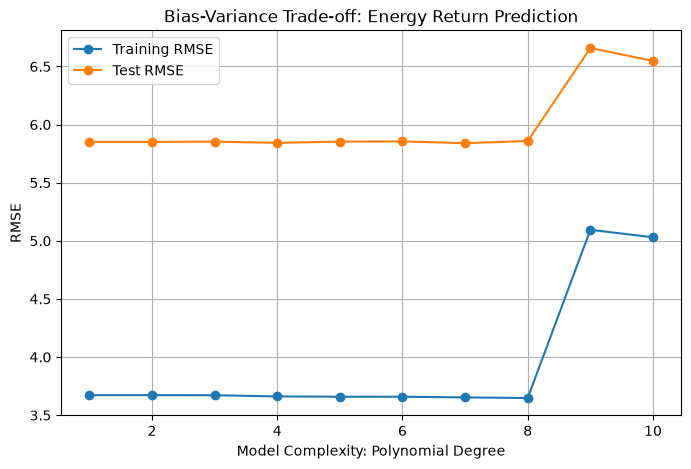

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    bias_variance_results["Polynomial Degree"],
    bias_variance_results["Training RMSE"],
    marker="o",
    label="Training RMSE"
)

plt.plot(
    bias_variance_results["Polynomial Degree"],
    bias_variance_results["Test RMSE"],
    marker="o",
    label="Test RMSE"
)

plt.xlabel("Model Complexity: Polynomial Degree")
plt.ylabel("RMSE")
plt.title("Bias-Variance Trade-off: Energy Return Prediction")
plt.legend()
plt.grid(True)

plt.show()

**Find the Best Degree**

In [17]:
best_model_row = bias_variance_results.loc[
    bias_variance_results["Test RMSE"].idxmin()
]

best_model_row

Polynomial Degree    7.000000
Training RMSE        3.652892
Test RMSE            5.839960
Name: 6, dtype: float64

### Interpretation of Bias-Variance Trade-off Results

This exercise examines the bias-variance trade-off by predicting Energy industry excess returns using market excess returns with increasing polynomial model complexity. Polynomial degrees from 1 to 10 were tested, and performance was evaluated using training RMSE and test RMSE.

The results show that increasing model complexity reduces training error only slightly from Degree 1 to Degree 8. However, the test RMSE remains almost unchanged across these models. The simple Degree 1 model has a test RMSE of 5.8508, while the best-performing model, Degree 7, has a test RMSE of 5.8400. This improvement is very small and does not justify the additional complexity of the higher-degree model.

For Degrees 9 and 10, test RMSE increases sharply, suggesting that very high-complexity models perform worse on unseen data. This illustrates the risk of overfitting and numerical instability when models become unnecessarily complex.

Overall, the results show that more complexity does not automatically lead to better prediction. In this case, a simple linear model is preferable because it is easier to interpret and performs almost as well as the more complex polynomial models. This exercise helps explain why regularization methods such as Ridge, LASSO, and Elastic Net are useful: they control model complexity and help reduce overfitting.

## END